1. Introduction

This project aims to develop a predictive model for insurance. The primary goal is to accurately forecast various insurance-related outcomes, such as claim probability, premium pricing, or policyholder churn. By leveraging historical data and machine learning techniques, this model can provide valuable insights for risk assessment, actuarial analysis, and targeted marketing strategies.

2. Objectives

Risk Assessment: Identify key factors influencing insurance claims and predict the likelihood of future claims.
Premium Optimization: Develop a model to suggest optimal premium rates based on individual risk profiles.
Customer Segmentation: Group policyholders based on their risk characteristics and behavioral patterns.
Fraud Detection (Optional): Identify suspicious claims that deviate significantly from predicted patterns.
3. Data Collection and Preparation

To build an effective model, a comprehensive dataset is crucial. This dataset typically includes:

Policyholder Demographics: Age, gender, occupation, marital status, location.
Policy Details: Coverage type, sum insured, policy start date, previous claims history.
Behavioral Data: Driving records (for auto insurance), health records (for health insurance), lifestyle factors.
Claim History: Date of claim, claim amount, type of claim.
Data preprocessing steps will involve:

Handling missing values (imputation).
Encoding categorical features (one-hot encoding, label encoding).
Feature scaling (standardization, normalization).
Feature engineering to create new predictive variables (e.g., 'age at policy start', 'claim frequency').
4. Methodology

Several machine learning algorithms can be employed for insurance prediction:

Regression Models (for premium prediction/claim amount):

Linear Regression
Ridge/Lasso Regression
Random Forest Regressor
Gradient Boosting Regressor (e.g., XGBoost, LightGBM)
Classification Models (for claim probability/fraud detection):

Logistic Regression
Decision Trees
Support Vector Machines (SVM)
Random Forest Classifier
Gradient Boosting Classifier
Clustering (for customer segmentation):

K-Means
DBSCAN
The choice of algorithm will depend on the specific prediction task and the nature of the data. Cross-validation techniques will be used to ensure model robustness and prevent overfitting.

5. Model Evaluation

Model performance will be evaluated using appropriate metrics:

For Regression Tasks: Mean Absolute Error (MAE), Mean Squared Error (MSE), R-squared.
For Classification Tasks: Accuracy, Precision, Recall, F1-score, ROC-AUC curve.
6. Expected Outcomes and Impact

The successful deployment of an insurance prediction model can lead to:

Improved Profitability: By accurately assessing risk and optimizing premiums, insurers can reduce losses and increase revenue.
Enhanced Customer Satisfaction: Fairer pricing and personalized services can lead to better customer retention.
Operational Efficiency: Automating parts of the underwriting process and claim assessment can streamline operations.
Reduced Fraud: Early detection of fraudulent claims can save significant costs.
7. Future Enhancements

Future work could include exploring advanced techniques like deep learning, incorporating real-time data streams, and developing explainable AI (XAI) features to provide transparent insights into model decisions.

In [4]:
#importing all the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [6]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
319,32,male,37.335,1,no,northeast,4667.60765
981,34,male,21.375,0,no,northeast,4500.33925
91,53,female,24.795,1,no,northwest,10942.13205
974,26,male,35.420,0,no,southeast,2322.62180
399,18,female,38.170,0,no,southeast,1631.66830


In [8]:
df.shape

(1338, 7)

In [9]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.select_dtypes(include='object').columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [12]:
df.select_dtypes(include=['float64','int64']).columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

Part 2: Dealing with missing values

In [13]:
missing_data = df.isnull()
print(missing_data.head())
for column in missing_data.columns.values.tolist():
  print(column)
  print(missing_data[column].value_counts())
  print(" ")

     age    sex    bmi  children  smoker  region  charges
0  False  False  False     False   False   False    False
1  False  False  False     False   False   False    False
2  False  False  False     False   False   False    False
3  False  False  False     False   False   False    False
4  False  False  False     False   False   False    False
age
age
False    1338
Name: count, dtype: int64
 
sex
sex
False    1338
Name: count, dtype: int64
 
bmi
bmi
False    1338
Name: count, dtype: int64
 
children
children
False    1338
Name: count, dtype: int64
 
smoker
smoker
False    1338
Name: count, dtype: int64
 
region
region
False    1338
Name: count, dtype: int64
 
charges
charges
False    1338
Name: count, dtype: int64
 


Text(0, 0.5, 'Count')

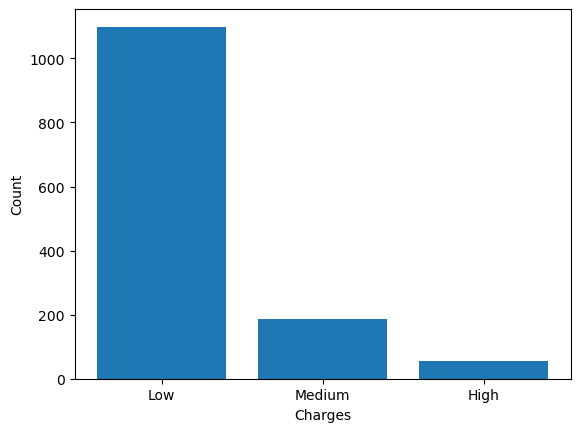

In [14]:
bin = np.linspace(min(df['charges']),max(df['charges']),4)
group_names = ["Low","Medium","High"]
df['charges_binned'] = pd.cut(df['charges'],bins=bin,labels=group_names,include_lowest=True)
plt.bar(group_names,df['charges_binned'].value_counts())
plt.xlabel("Charges")
plt.ylabel("Count")

Grouping the dataset by sex, smoker and region

In [15]:
df.groupby('smoker').mean(numeric_only=True)

,age,bmi,children,charges
smoker,,,,
no,39.385338,30.651795,1.090226,8434.268298
yes,38.514599,30.708449,1.113139,32050.231832


'''On average smokers pay almost 4 times as much as non-smokers'''

In [17]:
df.groupby('region').mean(numeric_only=True)

,age,bmi,children,charges
region,,,,
northeast,39.268519,29.173503,1.046296,13406.384516
northwest,39.196923,29.199785,1.147692,12417.575374
southeast,38.939560,33.355989,1.049451,14735.411438
southwest,39.455385,30.596615,1.141538,12346.937377


In [18]:
df.groupby('sex').mean(numeric_only=True)

,age,bmi,children,charges
sex,,,,
female,39.503021,30.377749,1.074018,12569.578844
male,38.917160,30.943129,1.115385,13956.751178



'''On average men pay more than women.'''


In [19]:
pearson_coef, p_value = stats.pearsonr(df['bmi'], df['charges'])
print(f"The Pearson Correlation Coefficient is", {pearson_coef})

The Pearson Correlation Coefficient is {np.float64(0.1983409688336289)}


Part 3: Feature Engineering



In [20]:
df.head()

,age,sex,bmi,children,smoker,region,charges,charges_binned
0,19,female,27.900,0,yes,southwest,16884.92400,Low
1,18,male,33.770,1,no,southeast,1725.55230,Low
2,28,male,33.000,3,no,southeast,4449.46200,Low
3,33,male,22.705,0,no,northwest,21984.47061,Low
4,32,male,28.880,0,no,northwest,3866.85520,Low


In [21]:
df = df.drop(columns='charges_binned')

In [22]:
#We convert out data using one hot encoding
dataset = pd.get_dummies(data=df,drop_first=True)
dataset.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [23]:
dataset_2 = dataset.drop(columns='charges')
dataset_2.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


<Axes: title={'center': 'Correlation with charges'}>

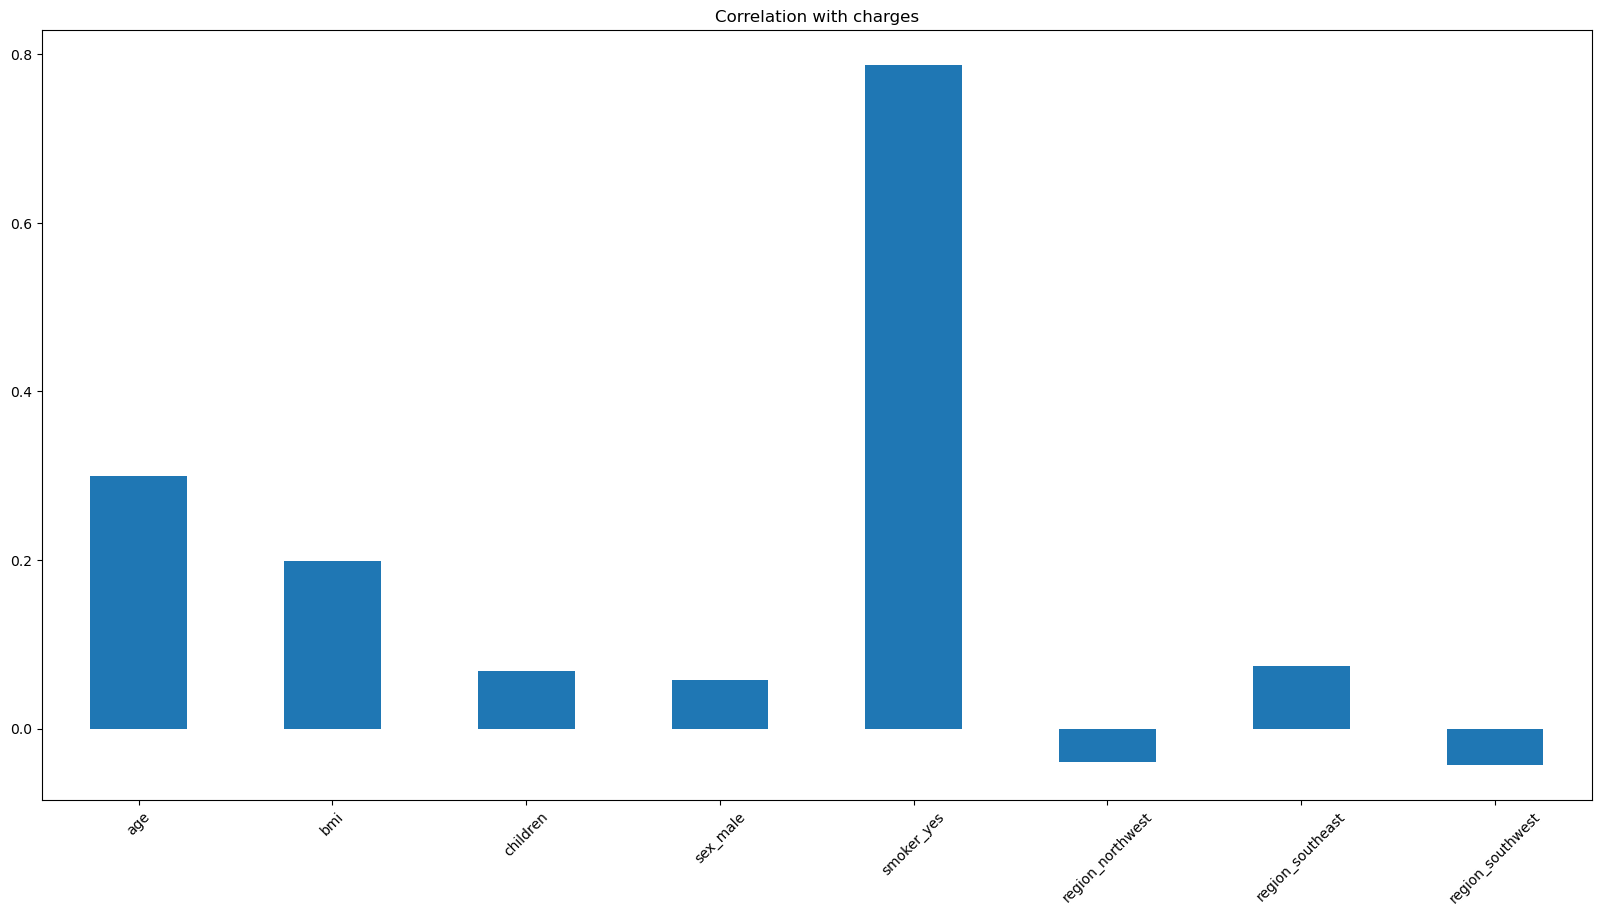

In [24]:
dataset_2.corrwith(dataset['charges']).plot.bar(
    figsize = (20, 10), title = "Correlation with charges",rot=45)

<Axes: >

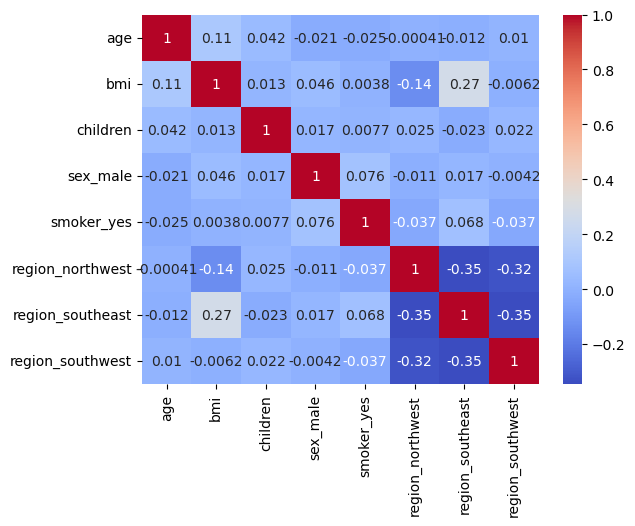

In [25]:
corr = dataset_2.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

Part 5: Splitting the dataset

In [26]:
#Create an independent variable
X = dataset.drop(columns='charges')

In [27]:
X.shape

(1338, 8)

In [29]:
y = dataset['charges']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [30]:
X_train.shape

(896, 8)

Part 6: Scaling the data

Data is scaled in machine learning to ensure all features contribute equally to model performance, preventing features with larger magnitudes from dominating those with smaller ranges.

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
X_train

array([[ 0.26510612, -0.91337479, -0.9126072 , ..., -0.58078691,
        -0.58594226, -0.55500378],
       [-0.01650038,  0.79545635,  0.74768935, ..., -0.58078691,
        -0.58594226,  1.80178953],
       [ 0.40590937, -0.00796181, -0.08245892, ...,  1.7218019 ,
        -0.58594226, -0.55500378],
       ...,
       [ 1.32113048, -0.89749036, -0.9126072 , ..., -0.58078691,
        -0.58594226, -0.55500378],
       [-0.15730363,  2.85207309,  0.74768935, ..., -0.58078691,
        -0.58594226,  1.80178953],
       [ 1.10992561, -0.10744856, -0.9126072 , ..., -0.58078691,
        -0.58594226,  1.80178953]])

Part 7: Building the ML models

In [35]:


from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train,y_train)

LinearRegression()

In [36]:
from sklearn.metrics import r2_score

In [37]:
pred = linear_model.predict(X_test)
score = r2_score(y_test,pred)
pred = linear_model.predict(X_test)

In [38]:
score = r2_score(y_test,pred)

In [39]:
score

0.7605492639270064

**Part 8: Predicting Charges For New Customer**

In [40]:
john = [[55,24,4,1,1,0,0,0]]

In [41]:
linear_model.predict(scaler.transform(john))

C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([35599.53822072])